# 07. Анализ спредов и срочности

Ноутбук соответствует третьей странице дашборда: анализ спреда доходности ОФЗ-ПД к ключевой ставке и связи спреда со сроком до погашения.

Используются только дневные данные ОФЗ-ПД с присоединённой ключевой ставкой.


## 1. Импорт и загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SUMMARY_DIR = DATA_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

for path in [SUMMARY_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [2]:
FIXED_PATH = PROCESSED_DIR / "fixed_datalens" / "ofz_fixed_with_key_rate_for_datalens.csv"

if not FIXED_PATH.exists():
    raise FileNotFoundError(f"Файл не найден: {FIXED_PATH.resolve()}. Сначала запустите 04_prepare_datalens_datasets.ipynb")

df = pd.read_csv(FIXED_PATH)
df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"], errors="coerce")

if "YIELD_KEY_RATE_SPREAD" not in df.columns:
    df["YIELD_KEY_RATE_SPREAD"] = df["YIELD_FOR_ANALYSIS"] - df["key_rate"]


def maturity_group(years):
    if pd.isna(years):
        return pd.NA
    if years <= 1:
        return "short"
    if years <= 5:
        return "medium"
    return "long"

if "MATURITY_GROUP" not in df.columns:
    df["MATURITY_GROUP"] = df["YEARS_TO_MATURITY"].map(maturity_group)

print("Fixed DataLens shape:", df.shape)
display(df.head())

Fixed DataLens shape: (13751, 15)


,TRADEDATE,SECID,SHORTNAME,COUPON_TYPE,PLOT_GROUP,PRICE_FOR_ANALYSIS,YIELD_FOR_ANALYSIS,RATE_FOR_ANALYSIS,YEARS_TO_MATURITY,DURATION,VALUE,key_rate,YIELD_KEY_RATE_SPREAD,RATE_KEY_RATE_SPREAD,MATURITY_GROUP
0,2016-05-04,SU26207RMFS9,ОФЗ 26207,fixed,long,95.5773,8.99,8.99,10.751540,2610.0,7.549269e+08,11.0,-2.01,-2.01,long
1,2016-05-05,SU26207RMFS9,ОФЗ 26207,fixed,long,95.6335,8.98,8.98,10.748802,2610.0,1.133353e+08,11.0,-2.02,-2.02,long
2,2016-05-06,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7770,8.95,8.95,10.746064,2610.0,2.091805e+08,11.0,-2.05,-2.05,long
3,2016-05-10,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7496,8.96,8.96,10.735113,2606.0,2.660816e+07,11.0,-2.04,-2.04,long
4,2016-05-11,SU26207RMFS9,ОФЗ 26207,fixed,long,96.3739,8.86,8.86,10.732375,2610.0,5.351472e+08,11.0,-2.14,-2.14,long


## 2. Дневная динамика среднего спреда

In [3]:
spread_daily = (
    df
    .groupby(["TRADEDATE", "MATURITY_GROUP"], as_index=False)
    .agg(
        avg_spread=("YIELD_KEY_RATE_SPREAD", "mean"),
        median_spread=("YIELD_KEY_RATE_SPREAD", "median"),
        avg_years_to_maturity=("YEARS_TO_MATURITY", "mean"),
        n_bonds=("SECID", "nunique"),
    )
    .sort_values(["TRADEDATE", "MATURITY_GROUP"])
)

display(spread_daily.head())

,TRADEDATE,MATURITY_GROUP,avg_spread,median_spread,avg_years_to_maturity,n_bonds
0,2016-05-04,long,-2.01,-2.01,10.751540,1
1,2016-05-05,long,-2.02,-2.02,10.748802,1
2,2016-05-06,long,-2.05,-2.05,10.746064,1
3,2016-05-10,long,-2.04,-2.04,10.735113,1
4,2016-05-11,long,-2.14,-2.14,10.732375,1


## 3. График спреда по группам срочности

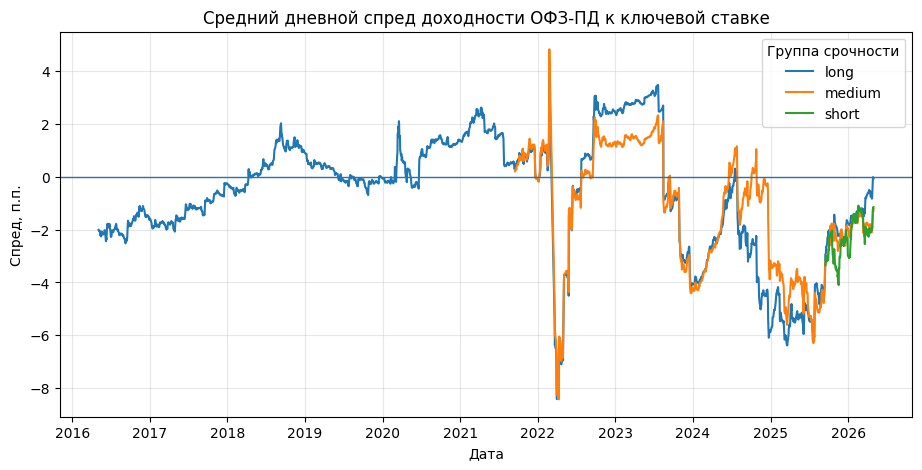

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_3_spread_by_maturity_group_daily.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for group_name, part in spread_daily.groupby("MATURITY_GROUP"):
    ax.plot(part["TRADEDATE"], part["avg_spread"], label=str(group_name))

ax.axhline(0, linewidth=1)
ax.set_title("Средний дневной спред доходности ОФЗ-ПД к ключевой ставке")
ax.set_xlabel("Дата")
ax.set_ylabel("Спред, п.п.")
ax.grid(True, alpha=0.3)
ax.legend(title="Группа срочности")

figure_path = FIGURES_DIR / "page_3_spread_by_maturity_group_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())

## 4. Связь срока до погашения и спреда

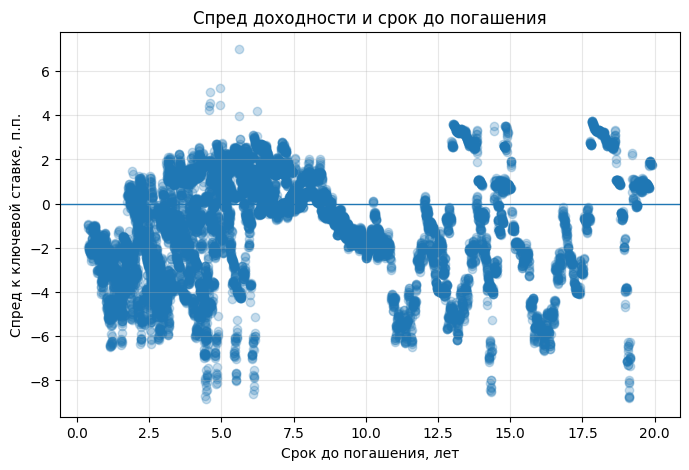

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_3_spread_vs_maturity_daily.png


In [5]:
scatter_df = df.dropna(subset=["YEARS_TO_MATURITY", "YIELD_KEY_RATE_SPREAD"]).copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(scatter_df["YEARS_TO_MATURITY"], scatter_df["YIELD_KEY_RATE_SPREAD"], alpha=0.25)
ax.axhline(0, linewidth=1)
ax.set_title("Спред доходности и срок до погашения")
ax.set_xlabel("Срок до погашения, лет")
ax.set_ylabel("Спред к ключевой ставке, п.п.")
ax.grid(True, alpha=0.3)

figure_path = FIGURES_DIR / "page_3_spread_vs_maturity_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())